In [1]:
!pip install control
!pip install mplcursors

import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import pandas as pd
import mplcursors
from IPython.display import display

!pip install --upgrade ipympl ipywidgets

!rm -f lugarraices.py && wget -O lugarraices.py https://raw.githubusercontent.com/nebisman/control-material/refs/heads/main/notebooks/lugarraices.py

from lugarraices import hacerLugarRaices, dibujarRegionDiseno

from google.colab import output
output.enable_custom_widget_manager()
%matplotlib widget



--2026-04-24 17:48:02--  https://raw.githubusercontent.com/nebisman/control-material/refs/heads/main/notebooks/lugarraices.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4902 (4.8K) [text/plain]
Saving to: ‘lugarraices.py’

lugarraices.py      100%[===================>]   4.79K  --.-KB/s    in 0s      

2026-04-24 17:48:02 (48.6 MB/s) - ‘lugarraices.py’ saved [4902/4902]



# Lugar de las raíces para el diseño de sistemas realimentados


## Tabla de contenidos
  [Ejemplo 1: levitador](#H_2382D06F)

    [**Actividad 1: Use el lugar de las raíces para diseñar un controlador proporcional en cada uno de los siguientes casos**](#H_066B7F8E)


   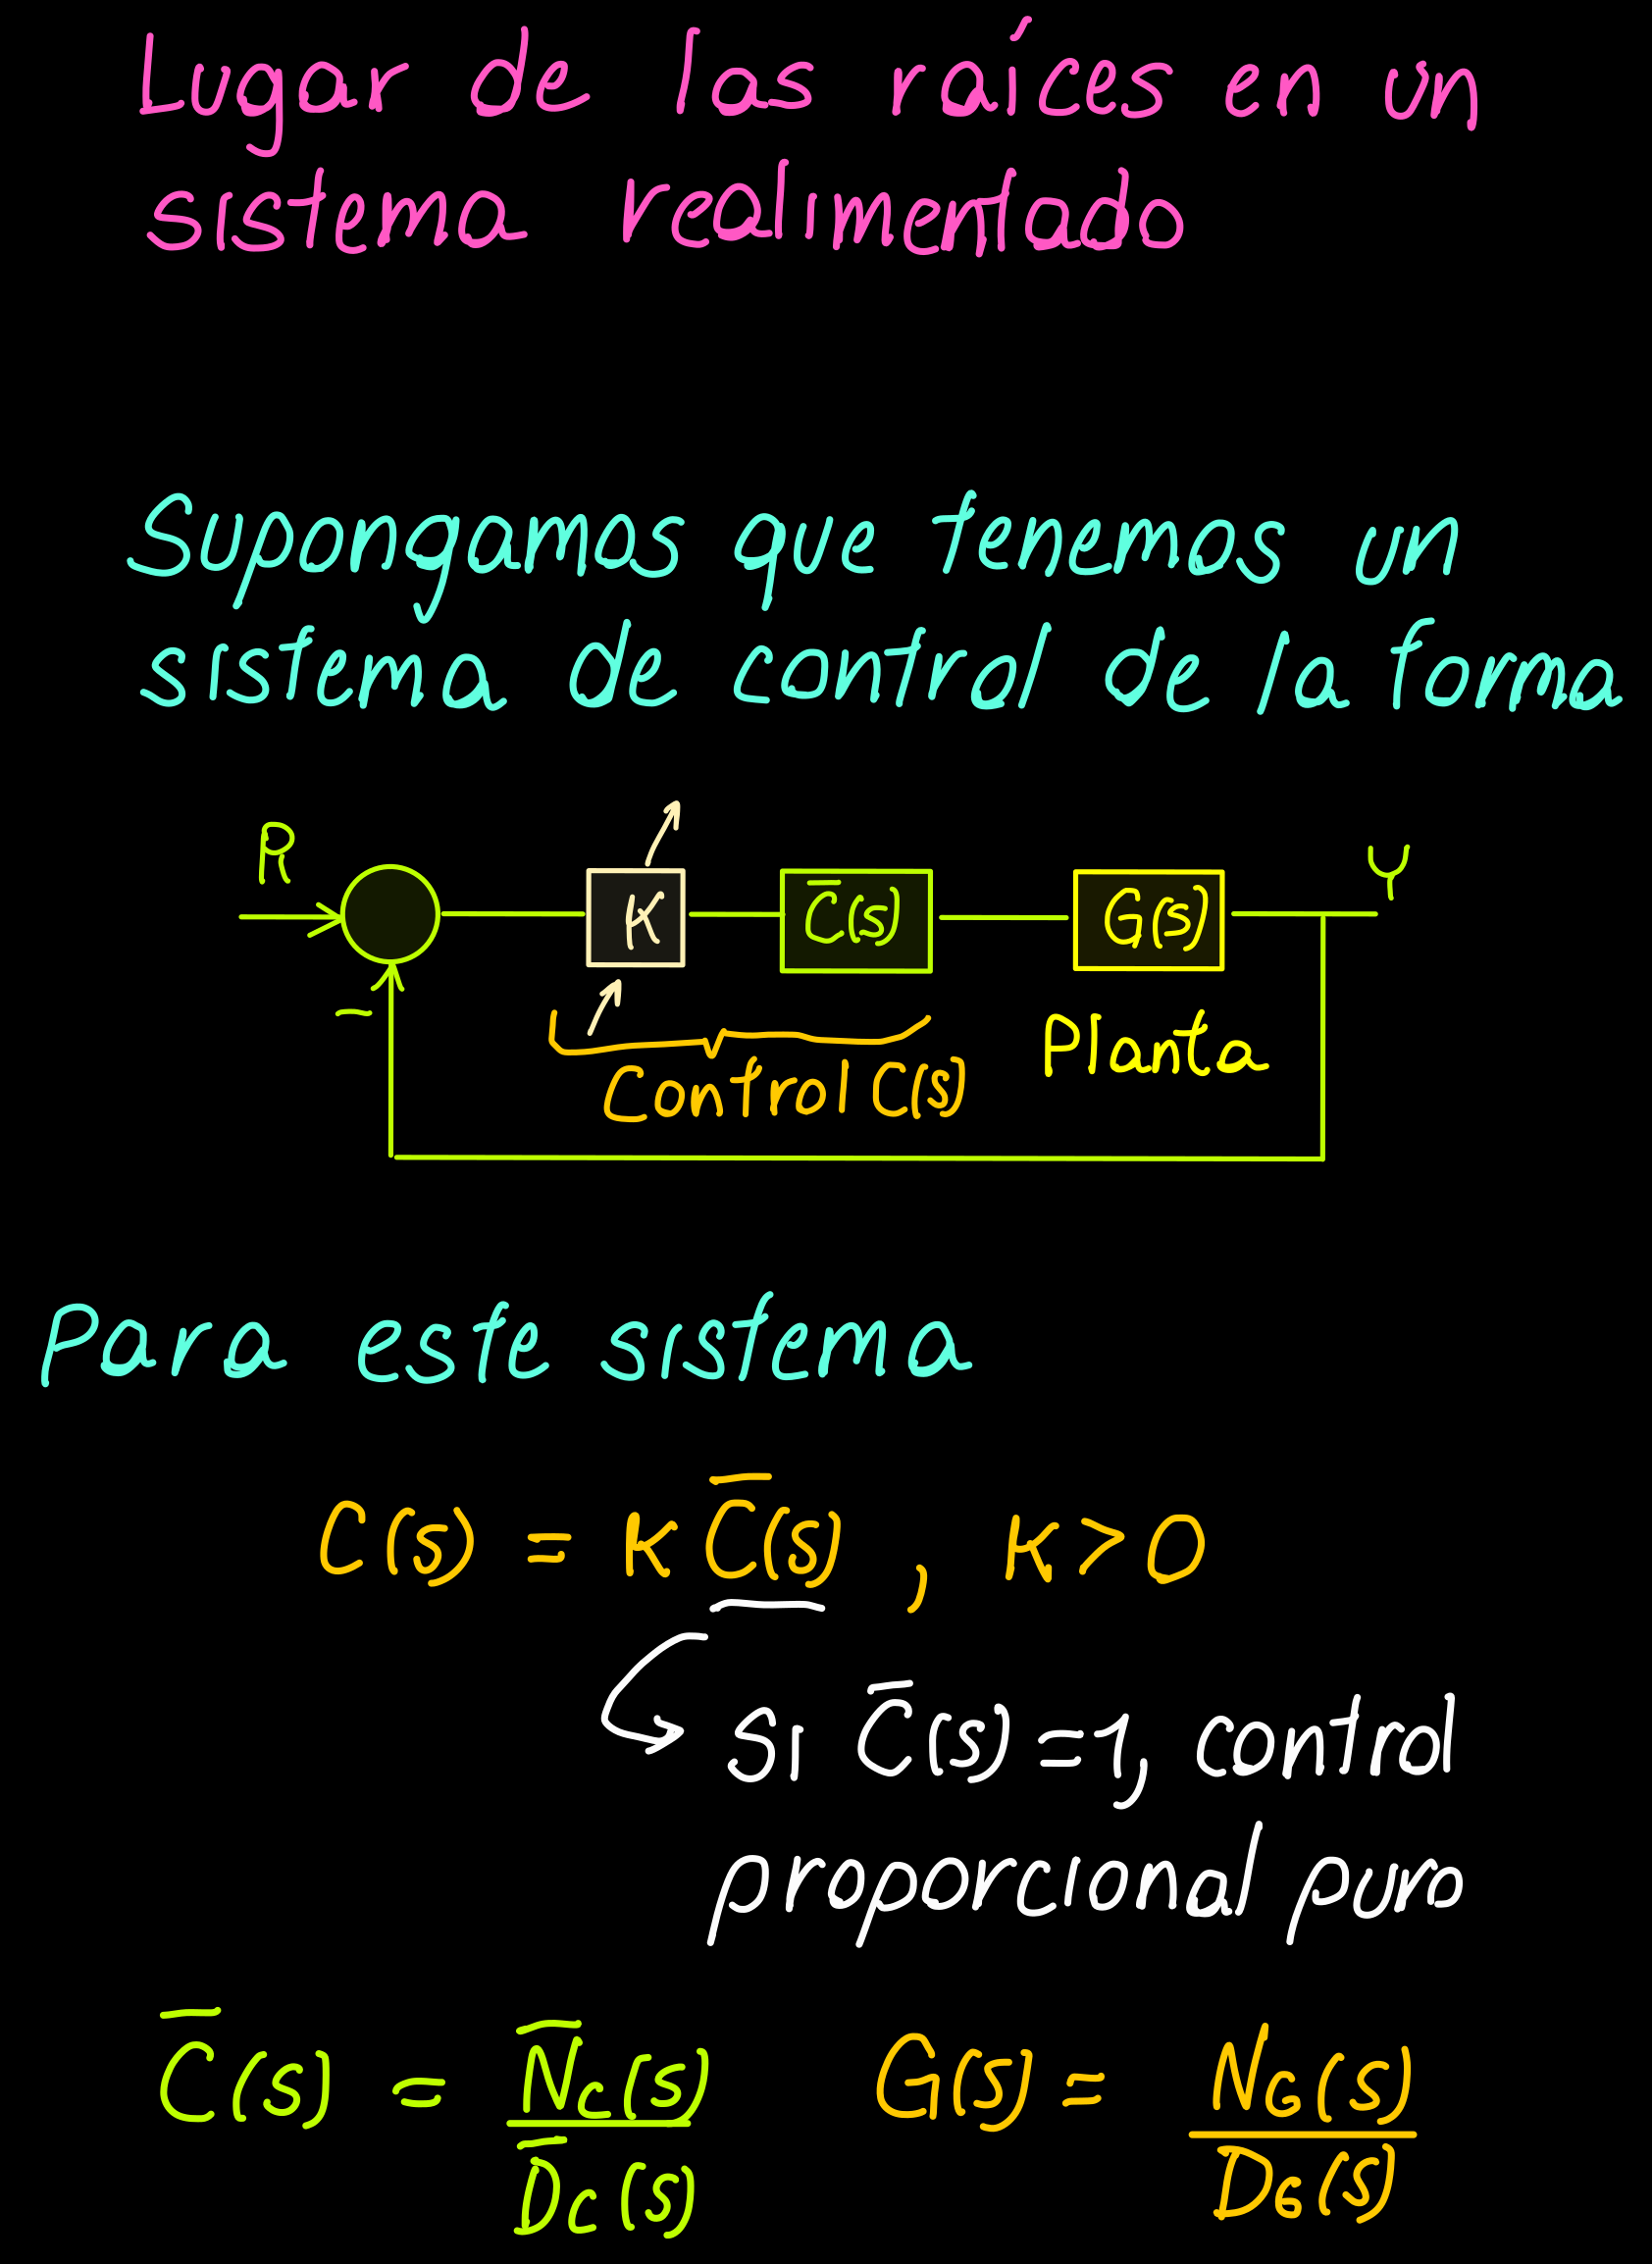


   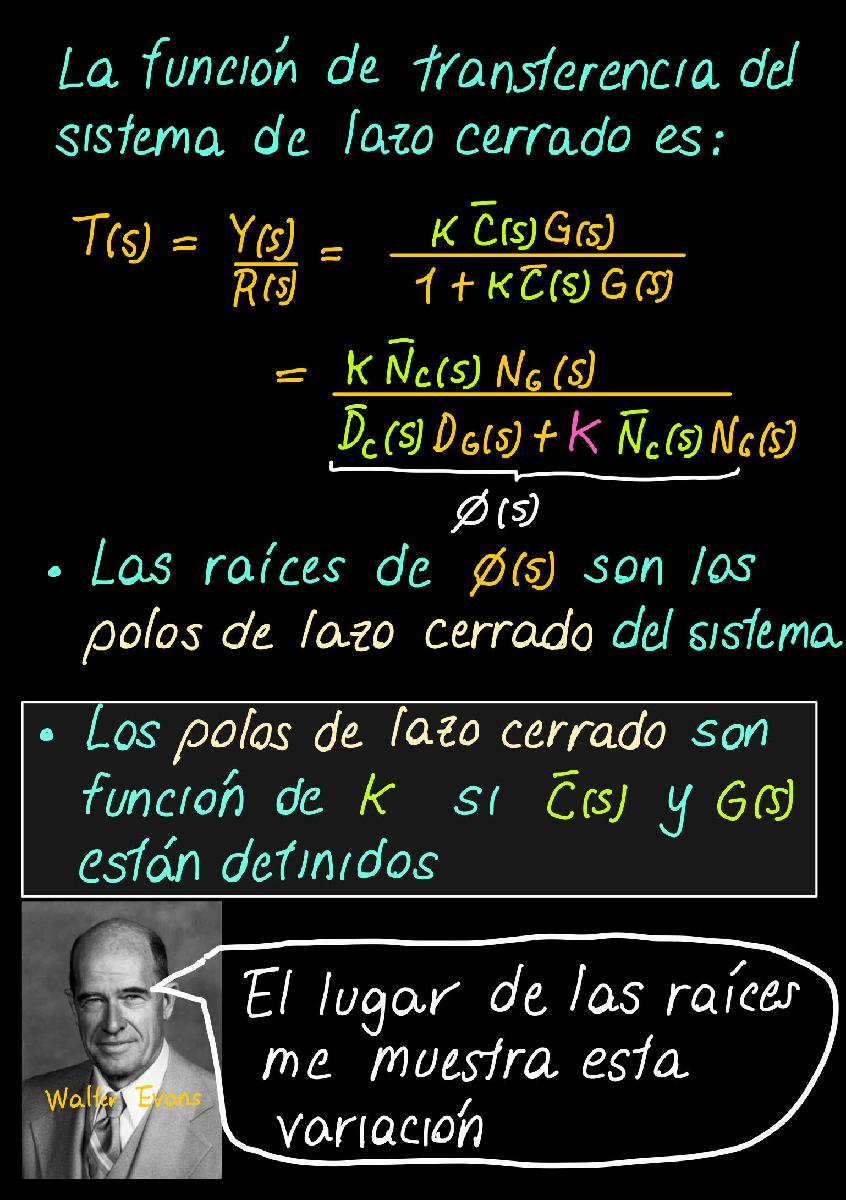


## Ejemplo 1: levitador

Supongamos que queremos diseñar un controlador para el levitador cuya función de transferencia fue encontrada en la actividad 1 (con otros parámetros). Dicha función de transferencia está dada por la siguiente expresión:


$$G(s)=\frac{182.27}{s(s+2.28)(s+3.664)}$$

In [2]:
s = ctrl.tf('s')
G = 182.27 / (s * (s + 2.28) * (s + 3.664))

Supongamos que le colocamos un controlador proporcional,


In [3]:
kp0 = 0.01
kpf = 0.39
points = 10
KP = np.linspace(kp0, kpf, points)

rows = []
for kp_i in KP:
    T = ctrl.feedback(kp_i * G, 1)
    poles = np.sort_complex(ctrl.poles(T))
    rows.append({'k': np.round(kp_i, 4),
                 'p1': np.round(poles[0], 4),
                 'p2': np.round(poles[1], 4),
                 'p3': np.round(poles[2], 4)})

df = pd.DataFrame(rows)
display(df)

,k,p1,p2,p3
0,0.0100,-3.9422+0.0000j,-1.7354+0.0000j,-0.2664+0.0000j
1,0.0522,-4.5722+0.0000j,-0.6859-1.2694j,-0.6859+1.2694j
2,0.0944,-4.9594+0.0000j,-0.4923-1.7969j,-0.4923+1.7969j
3,0.1367,-5.2563+0.0000j,-0.3439-2.1496j,-0.3439+2.1496j
4,0.1789,-5.5027+0.0000j,-0.2207-2.4242j,-0.2207+2.4242j
5,0.2211,-5.7160+0.0000j,-0.1140-2.6529j,-0.1140+2.6529j
6,0.2633,-5.9056+0.0000j,-0.0192-2.8508j,-0.0192+2.8508j
7,0.3056,-6.0773+0.0000j,0.0667-3.0265j,0.0667+3.0265j
8,0.3478,-6.2348+0.0000j,0.1454-3.1853j,0.1454+3.1853j
9,0.3900,-6.3807+0.0000j,0.2184-3.3306j,0.2184+3.3306j


Ahora vamos a dibujar la región de diseño con las especificaciones:


$$\begin{array}{l} t_{ee} \le 8s\newline t_r \le 4s\newline SP\le 10\newline  \end{array}$$


Para esto usamos las fórmulas de la región de diseño, vistas antes.


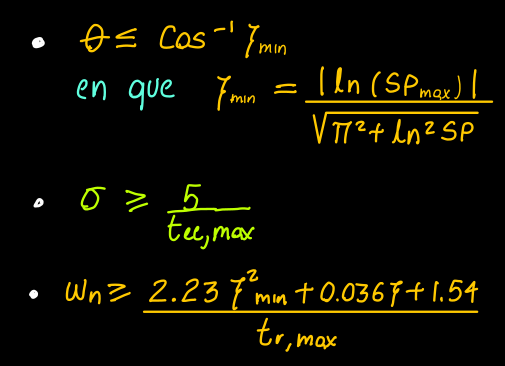


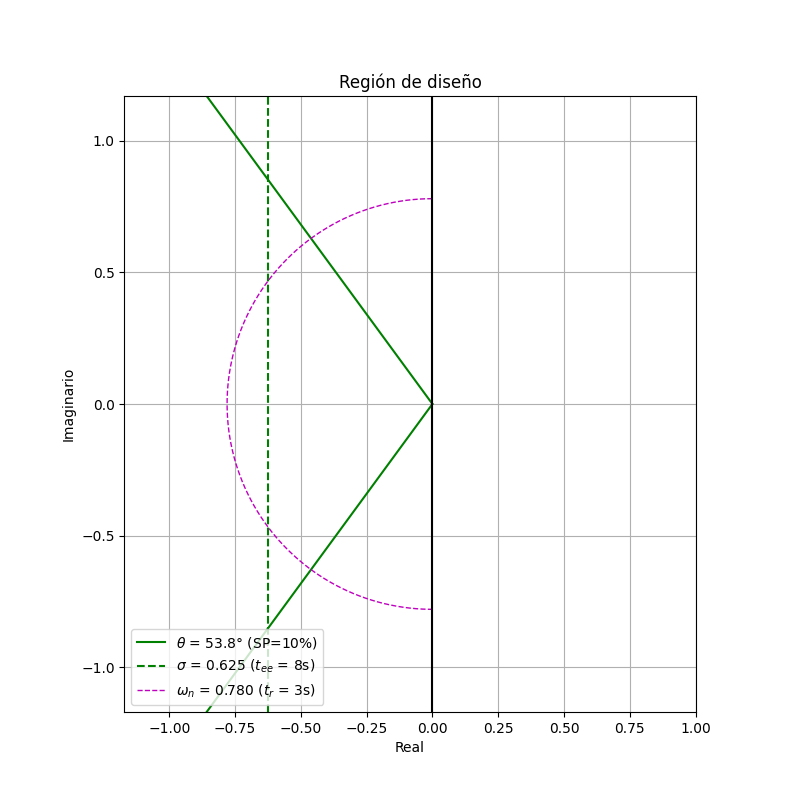

In [4]:
SP_max = 0.1
tee_max = 8
tr_max = 3
dibujarRegionDiseno(SP_max, tee_max, tr_max)


Ahora hacemos el lugar de las raices

/usr/local/lib/python3.12/dist-packages/control/rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


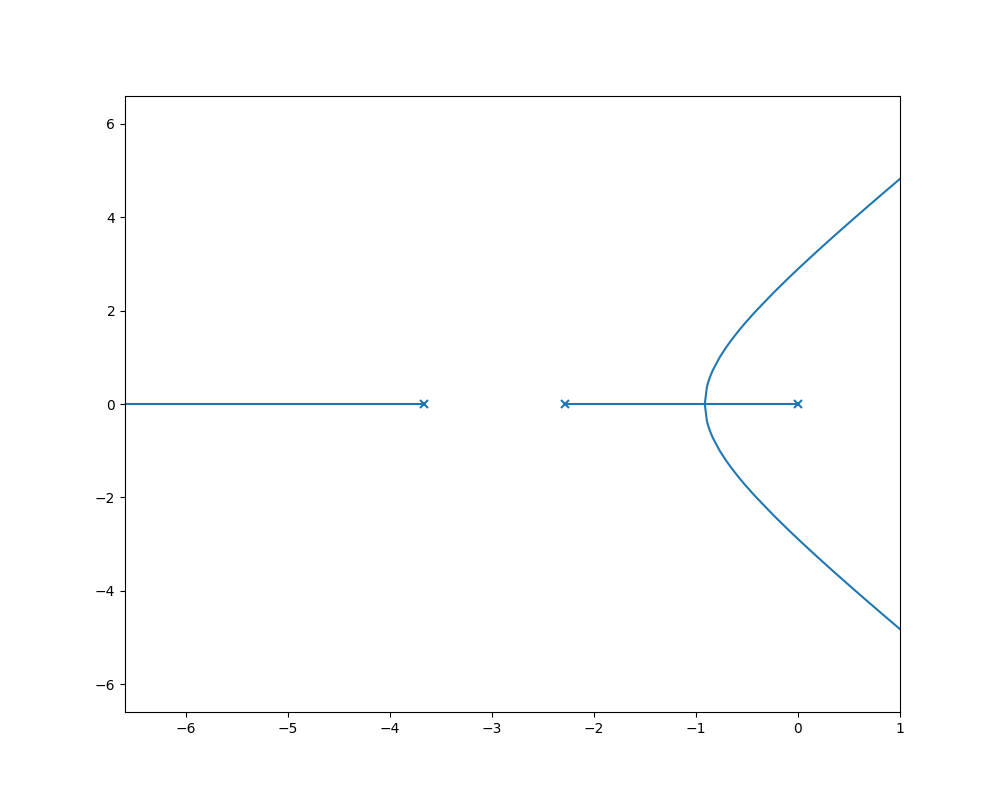

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
rlist, klist = ctrl.root_locus(G, plot=True, ax=ax)


## Lugar de las raices y región de diseño
Ahora hacemos  el lugar de las raices y la región de diseño


/usr/local/lib/python3.12/dist-packages/control/rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


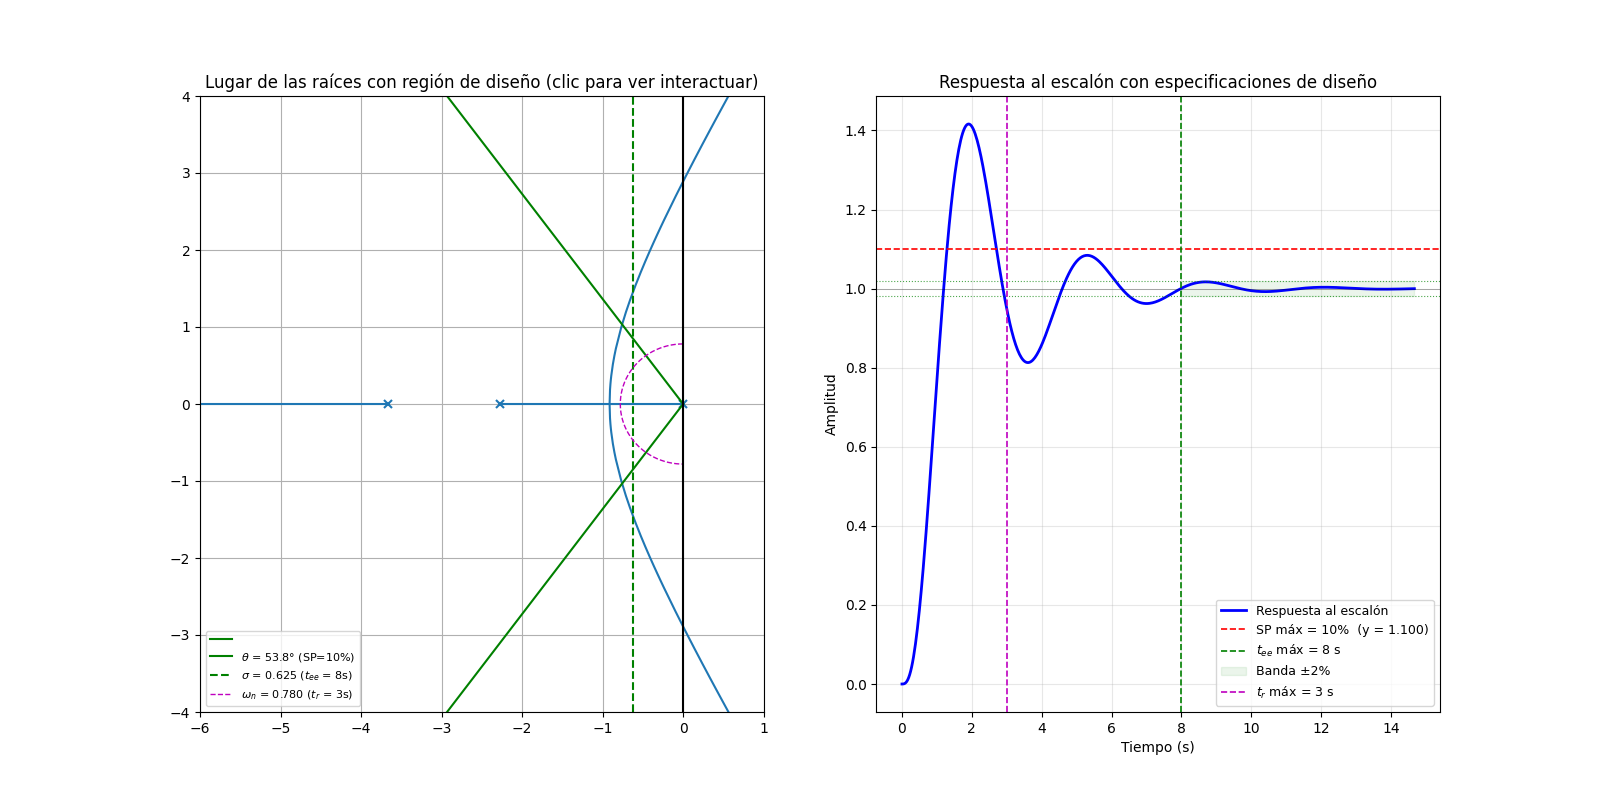

In [9]:
hacerLugarRaices(G, SP_max, tee_max, tr_max)

Por ejempo en el cruce del lugar de las raíces con la linea de sobrepico:

In [10]:
s0 = -0.769+0.99j

Por la condición de magnitud


In [11]:
k = abs((s0 * (s0 + 3.66) * (s0 + 2.28)) / 182.7)
print(f'k = {k}')

k = 0.03787590275536378


In [ ]:
T = ctrl.feedback(k * G, 1)
print('Polos del sistema en lazo cerrado:')
print(ctrl.poles(T))

Polos del sistema en lazo cerrado:
[-4.03291705+0.j -1.47166018+0.j -0.43942277+0.j]


### **Actividad 1: Use el lugar de las raíces para diseñar un controlador proporcional en cada uno de los siguientes casos**
-  $\displaystyle SP_{max} \approx 5\%$
-  $\displaystyle SP=0$

